## Fig. 4a & 4b

In [ ]:
def plot_relLoc_vs_theta_heatmap_simple(
    theta_cycles_day,
    bin_deg=20,
    ylim=(-20, 20),
    cmap="jet",
    ax=None,
    shift_deg=180
):
    phases_list = []
    post_list = []
    s_centers = None

    for cyc in theta_cycles_day:
        if not all(k in cyc for k in ["phase_deg", "rel_posterior_1d", "rel_s_centers"]):
            continue

        ph = np.asarray(cyc["phase_deg"], dtype=float)
        P1 = np.asarray(cyc["rel_posterior_1d"], dtype=float)
        centers = np.asarray(cyc["rel_s_centers"], dtype=float)

        if P1.ndim != 2 or ph.ndim != 1:
            continue

        if s_centers is None:
            s_centers = centers
        elif len(s_centers) != P1.shape[1]:
            continue

        keep = np.isfinite(ph) & np.all(np.isfinite(P1), axis=1)
        ph = ph[keep] % 360
        P1 = P1[keep]

        if ph.size == 0:
            continue

        if shift_deg is not None:
            ph = (ph - shift_deg) % 360

        phases_list.append(ph)
        post_list.append(P1)

    if not phases_list:
        return None

    phases = np.concatenate(phases_list)
    post1d = np.vstack(post_list)

    nb = int(360 // bin_deg)
    bin_id = np.clip(np.floor(phases / bin_deg).astype(int), 0, nb - 1)
    H = np.zeros((nb, post1d.shape[1]), dtype=float)

    for b in range(nb):
        idx = bin_id == b

        if not np.any(idx):
            continue

        row = np.nansum(post1d[idx], axis=0)
        row[row < 0] = 0

        total = row.sum()

        if total > 0:
            H[b] = row / total

    Z = np.vstack([H, H]).T

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4.6), dpi=140)

    ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[0, 720, s_centers[0], s_centers[-1]],
        cmap=cmap,
        interpolation="bilinear"
    )

    ax.axhline(0, color="white", linestyle="--", linewidth=1.2, alpha=0.9, zorder=5)

    ax.set_xlim(0, 720)
    ax.set_ylim(ylim)
    ax.set_xticks([0, 360, 720])
    ax.set_yticks(np.linspace(ylim[0], ylim[1], 5))
    ax.set_xlabel("Theta phase (°)", fontsize=10, fontname="Arial")
    ax.set_ylabel("Relative location (cm)", fontsize=10, fontname="Arial")
    ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=9)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Arial")
    return ax
def plot_one_animal_days_720_simple(
    theta_cycles,
    animal,
    env="VR",
    days=(2, 15),
    ncols=2,
    bin_deg=20,
    ylim=(-20, 20),
    cmap="jet",
    shift_deg=180,
    cell_w=1.6,
    cell_h=3
):
    days = [int(d) for d in days]
    nrows = int(math.ceil(len(days) / ncols))

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * cell_w, nrows * cell_h),
        dpi=140,
        sharex=True,
        sharey=True
    )
    axs = np.atleast_1d(axs).ravel()
    cycles_by_day = {}
    for cyc in theta_cycles:
        if cyc.get("animal") != animal:
            continue
        if "env" in cyc and cyc.get("env") != env:
            continue

        day = int(cyc.get("day", -1))
        cycles_by_day.setdefault(day, []).append(cyc)

    plotted = 0

    for k, day in enumerate(days):
        ax = axs[k]

        out = plot_relLoc_vs_theta_heatmap_simple(
            cycles_by_day.get(day, []),
            bin_deg=bin_deg,
            ylim=ylim,
            cmap=cmap,
            ax=ax,
            shift_deg=shift_deg
        )
        if out is not None:
            plotted += 1

        if k % ncols != 0:
            ax.set_ylabel("")
            ax.set_xlabel("")
        if k == 0:
            ax.set_title("Early", fontname="Arial", fontsize=10)
        elif k == 1:
            ax.set_title("Late", fontname="Arial", fontsize=10)

    for ax in axs[len(days):]:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    print(f"Plotted {plotted}/{len(days)} days for {animal} ({env}).")

    return fig

Plotted 2/2 days for m57 (VR).


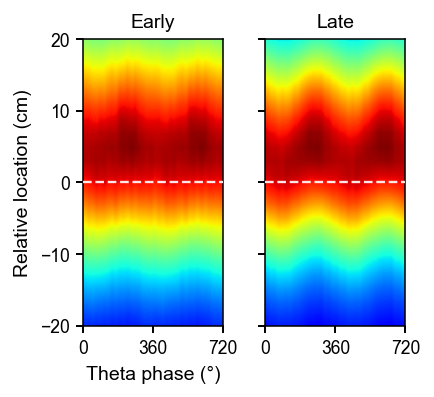

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ANIMAL   = "m57"
ENV      = "VR"
df = pd.read_pickle(r"../Results4Plots/m57_VR.pkl")
df = df.copy()
fig = plot_one_animal_days_720_simple(
    theta_cycles=df,
    animal=ANIMAL,
    env=ENV,
    days=[2, 15],
    ncols=2,
    bin_deg=20,
    ylim=(-20, 20),
    shift_deg=180,
    cmap="jet",
)

Plotted 2/2 days for m57 (R).


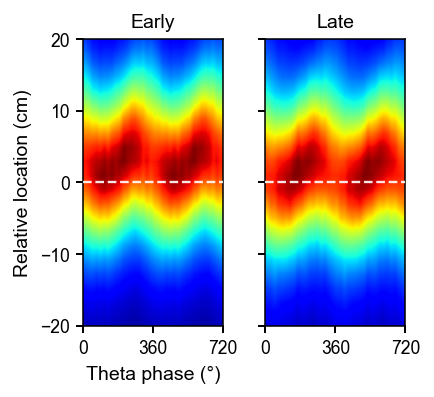

In [ ]:
ANIMAL   = "m57"
ENV      = "R"
df = pd.read_pickle(r"../Results4Plots/m57_R.pkl")
df = df.copy()
fig = plot_one_animal_days_720_simple(
    theta_cycles=df,
    animal=ANIMAL,
    env=ENV,
    days=[2, 15],
    ncols=2,
    bin_deg=20,
    ylim=(-20, 20),
    shift_deg=180,
    cmap="jet",
)

## Fig. 4c


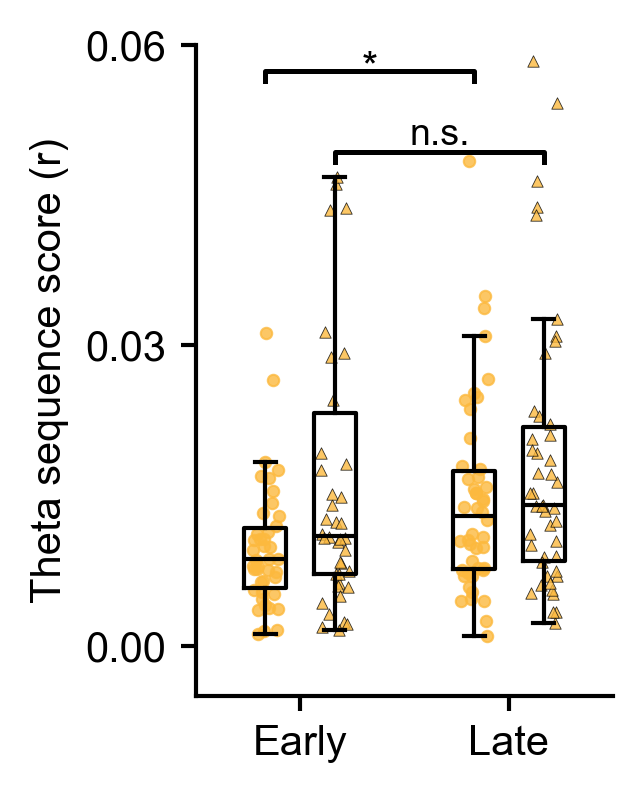

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/Theta_sequence_score.csv")
df["WeightedCorr"] = pd.to_numeric(df["WeightedCorr"], errors="coerce").abs()

df = df[
    (df["stage"].isin(["early", "late"]))
    & (df["env"].isin(["R", "VR"]))
    & (df["WeightedCorr"].notna())
].copy()

stage_levels = ["early", "late"]
env_levels = ["R", "VR"]

colorTheta = np.array([252, 185, 62]) / 255.0

xpos = {
    ("early", "VR"): 1,
    ("early", "R"): 2,
    ("late", "VR"): 4,
    ("late", "R"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2, 2.5), dpi=300)

for st in stage_levels:
    for env in env_levels:
        sub = df[(df["stage"] == st) & (df["env"] == env)]
        y = sub["WeightedCorr"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, env)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if env == "VR":
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorTheta, edgecolors=colorTheta, linewidths=0.5, alpha=0.8, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors=colorTheta, edgecolors="k", linewidths=0.2, alpha=0.8, zorder=1)

        ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Theta sequence score (r)", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.01 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

r_values = df.loc[df["env"] == "R", "WeightedCorr"].to_numpy(dtype=float)
vr_values = df.loc[df["env"] == "VR", "WeightedCorr"].to_numpy(dtype=float)

r_values = r_values[np.isfinite(r_values)]
vr_values = vr_values[np.isfinite(vr_values)]

y_r = np.nanmax(r_values) + gap - 0.052
y_vr = np.nanmax(vr_values) + gap + 0.12 * yr - 0.007

ax.plot([2, 2, 5, 5], [y_r, y_r + h, y_r + h, y_r], lw=1.2, c="k")
ax.text(3.5, y_r + h + text_offset - 0.001, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([1, 1, 4, 4], [y_vr, y_vr + h, y_vr + h, y_vr], lw=1.2, c="k")
ax.text(2.5, y_vr + h + text_offset - 0.03 * yr + 0.0005, "*", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.set_ylim(-0.005, 0.06)
ax.set_yticks([0, 0.03, 0.06])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 4e

In [46]:
def get_steps(Replay_trajs, timeb=1):
    all_steps = []
    for replay_traj in Replay_trajs:
        if len(replay_traj) < timeb:
            continue
        traj_step = np.sqrt(np.diff(replay_traj[::timeb,0])**2 + np.diff(replay_traj[::timeb,1])**2)
        all_steps = np.concatenate((all_steps, traj_step))
    
    return all_steps
def get_diffusion_exponent(Replay_trajs, stepnums = 20): 
    
    #return plt
    all_timebins = np.arange(1,stepnums,1)
    all_avg_steps = []
    for timeb in all_timebins:
        all_steps = get_steps(Replay_trajs, timeb)
        avg_step = np.mean(all_steps)
        all_avg_steps.append(avg_step)
    slope, intercept = np.polyfit(np.log(all_timebins), np.log(all_avg_steps), 1)
    return slope, intercept, all_timebins, all_avg_steps
def brownian_motion_2d(n_steps=50, box_size=60, step_std=2.0, start_pos=None):
    if start_pos is None:
        start_pos = np.array([box_size / 2, box_size / 2])
    steps = np.random.normal(0.0, step_std, size=(n_steps, 2))
    traj = np.cumsum(steps, axis=0) + start_pos
    traj = np.clip(traj, 0, box_size)
    return traj[:, 0], traj[:, 1]


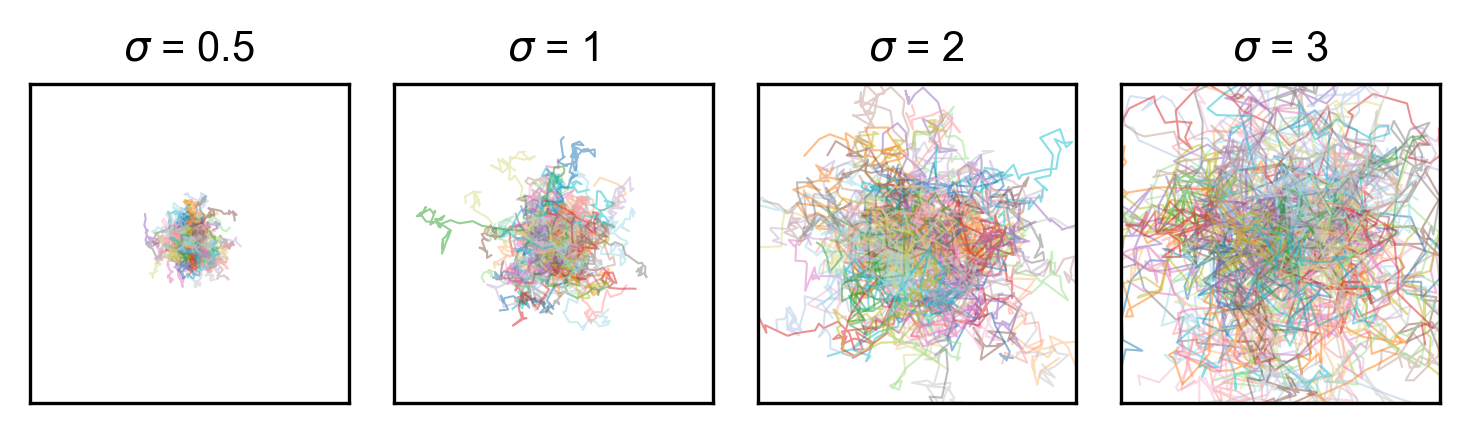

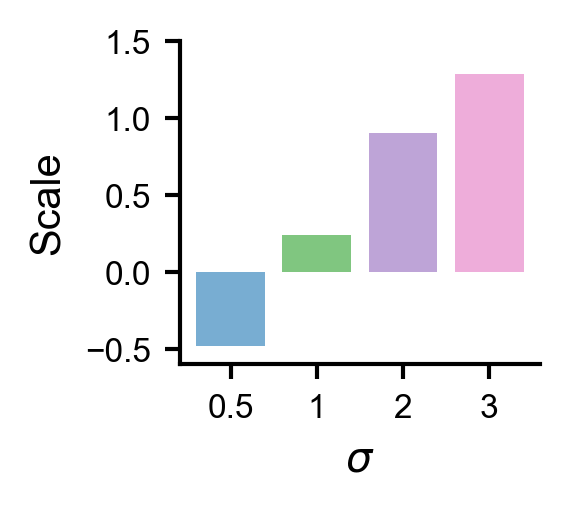

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
std_values = [0.5, 1, 2, 3]
n_traj = 100
n_steps = 50
box_size = 60

cmap = plt.get_cmap("tab20")
intercepts = []

fig, axs = plt.subplots(1, len(std_values), figsize=(5, 1.8), dpi=300)

for ax, step_std in zip(axs, std_values):
    trajectories = []

    for _ in range(n_traj):
        x, y = brownian_motion_2d(n_steps=n_steps, box_size=box_size, step_std=step_std)
        trajectories.append(np.column_stack((x, y)))

    _, replay_intercept, _, _ = get_diffusion_exponent(trajectories, stepnums=20)
    intercepts.append(replay_intercept)

    for i, traj in enumerate(trajectories):
        ax.plot(traj[:, 0], traj[:, 1], lw=0.5, alpha=0.5, color=cmap(i % 20))

    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(rf"$\sigma$ = {step_std}", fontname="Arial", fontsize=10)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2, 1.8), dpi=300)

colors = [cmap(i) for i in [0, 4, 8, 12]]

ax.bar([str(s) for s in std_values], intercepts, color=colors, alpha=0.6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_xlabel(r"$\sigma$", fontname="Arial", fontsize=10)
ax.set_ylabel("Scale", fontname="Arial", fontsize=10)
ax.set_ylim(-0.6, 1.5)
ax.set_yticks([-0.5, 0, 0.5, 1, 1.5])

plt.tight_layout()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\X Yang\AppData\Local\Temp\ipykernel_608\1887103959.py:16: SyntaxWarning: invalid escape sequence '\s'
  label=f'$\sigma$={step_std}',
C:\Users\X Yang\AppData\Local\Temp\ipykernel_608\1887103959.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20')


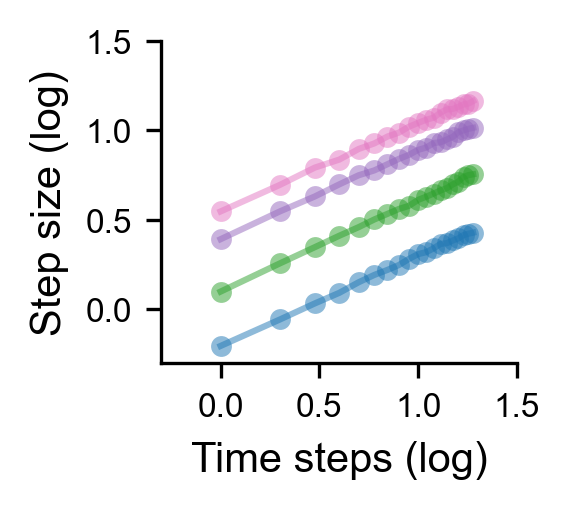

In [51]:
fig, ax = plt.subplots(figsize=(2, 1.8), dpi=300)
tab20 = plt.cm.get_cmap('tab20')
colors = [tab20(i) for i in [0, 4, 8, 12, 16]]
for step_std, color in zip(std_values, colors):
    trajectories = []
    for i in range(n_traj):
        x, y = brownian_motion_2d(n_steps=n_steps, box_size=box_size, step_std=step_std)
        traj_xy = np.column_stack((x, y))
        trajectories.append(traj_xy)

    _, _, time_bins, ave_steps = get_diffusion_exponent(trajectories, stepnums=20)
    
    ax.plot(
        np.log10(time_bins), np.log10(ave_steps),
        marker='o', color=color,
        label=f'$\sigma$={step_std}',  
        markersize=5, alpha=0.5, markeredgecolor='none'
    )

ax.set_xlabel('Time steps (log)', fontname="Arial", fontsize=10)
ax.set_ylabel('Step size (log)', fontname="Arial", fontsize=10)
ax.set_ylim(-0.3, 1.5)
ax.set_yticks([ 0, 0.5, 1, 1.5])
ax.set_xlim(-0.3, 1.5)
ax.set_xticks([ 0, 0.5, 1, 1.5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")
plt.tight_layout()

## Fig. 4f

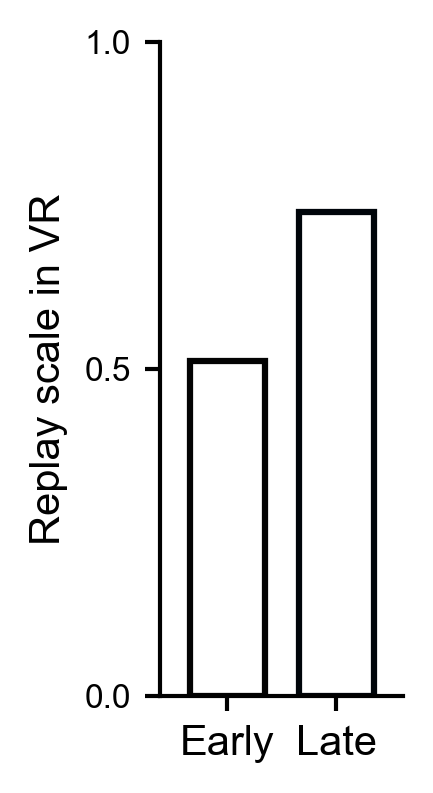

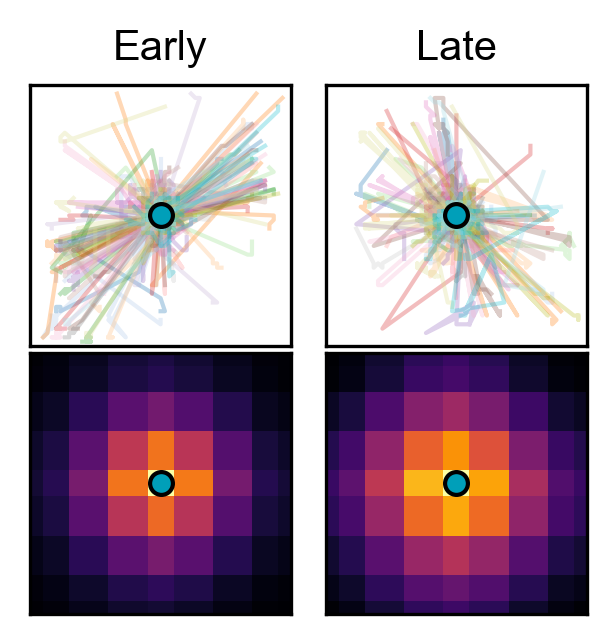

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = np.load("../Results4Plots/VR_m48.npy", allow_pickle=True).item()

stage_names = list(plot_data["stage_names"])
mean_values = plot_data["replay_scale"]
plot_trajs = plot_data["trajectories"]
mean_posterior = plot_data["mean_posterior"]
grid_x = plot_data["grid_x"]
grid_y = plot_data["grid_y"]

GX, GY = np.meshgrid(grid_x, grid_y)

bar_x = np.array([1, 2.3])
edge_colors = ["#030303FF", "#00050A"]

fig, ax = plt.subplots(figsize=(1.3, 2.5), dpi=300)

ax.bar(bar_x, mean_values, facecolor="none", edgecolor=edge_colors, linewidth=1.5, width=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=8)

ax.set_ylabel("Replay scale in VR", fontsize=10, fontname="Arial")
ax.set_xticks(bar_x)
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
ax.set_xlim(0.2, 3.1)
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.5, 1])

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

fig.tight_layout(pad=0.2)
plt.show()

fig, axes = plt.subplots(2, len(stage_names), figsize=(2, 2), dpi=300, squeeze=False)
fig.subplots_adjust(wspace=0.2, hspace=0.17)

cmap = plt.get_cmap("tab20")

for i, sname in enumerate(stage_names):
    ax_traj = axes[0, i]
    trajs = plot_trajs[sname]

    colors = [cmap(j / len(trajs)) for j in range(len(trajs))]

    for j, traj in enumerate(trajs):
        ax_traj.plot(traj["x"], traj["y"], color=colors[j], linewidth=1.0, alpha=0.3, zorder=1)

    ax_traj.scatter(0, 0, c="#009FB9", s=30, edgecolor="k", marker="o", zorder=10)

    ax_traj.set_title(sname.capitalize(), fontsize=10, fontname="Arial")
    ax_traj.set_aspect("equal")
    ax_traj.set_xlim(-60, 60)
    ax_traj.set_ylim(-60, 60)
    ax_traj.set_xticks([])
    ax_traj.set_yticks([])

    ax_post = axes[1, i]

    ax_post.pcolormesh(GX, GY, mean_posterior[sname], cmap="inferno", shading="auto")
    ax_post.scatter(0, 0, c="#009FB9", s=30, edgecolor="k", marker="o", zorder=10)

    ax_post.set_aspect("equal")
    ax_post.set_xticks([])
    ax_post.set_yticks([])

fig.tight_layout(pad=0.2)
plt.show()

## Fig. 4g

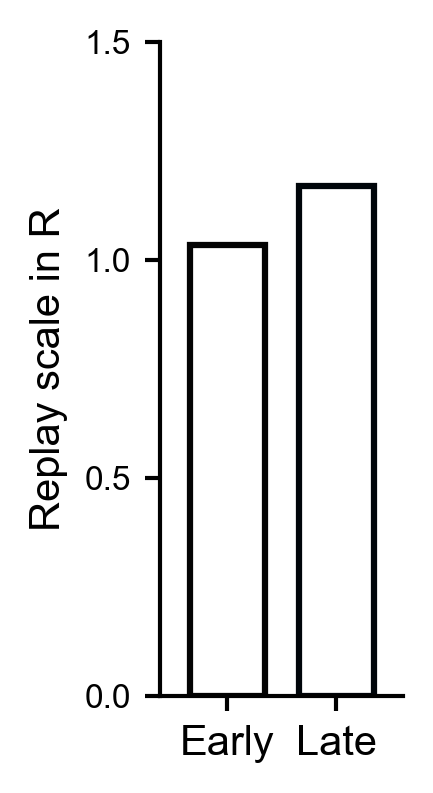

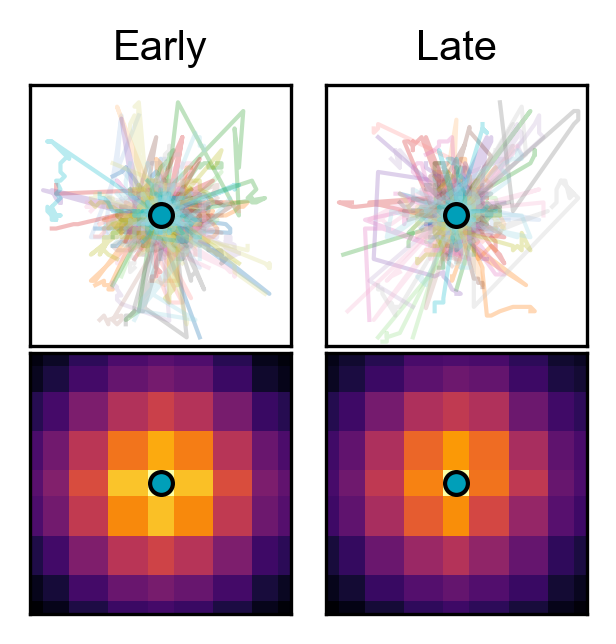

In [ ]:
plot_data = np.load("../Results4Plots/R_m48.npy", allow_pickle=True).item()

stage_names = list(plot_data["stage_names"])
mean_values = plot_data["replay_scale"]
plot_trajs = plot_data["trajectories"]
mean_posterior = plot_data["mean_posterior"]
grid_x = plot_data["grid_x"]
grid_y = plot_data["grid_y"]

GX, GY = np.meshgrid(grid_x, grid_y)

bar_x = np.array([1, 2.3])
edge_colors = ["#030303FF", "#00050A"]

fig, ax = plt.subplots(figsize=(1.3, 2.5), dpi=300)

ax.bar(bar_x, mean_values, facecolor="none", edgecolor=edge_colors, linewidth=1.5, width=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=8)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Replay scale in R", fontsize=10, fontname="Arial")
ax.set_xticks(bar_x)
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
ax.set_xlim(0.2, 3.1)
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.5, 1, 1.5])

fig.tight_layout(pad=0.2)
plt.show()

fig, axes = plt.subplots(2, len(stage_names), figsize=(2, 2), dpi=300, squeeze=False)
fig.subplots_adjust(wspace=0.2, hspace=0.17)

cmap = plt.get_cmap("tab20")

for i, sname in enumerate(stage_names):
    ax_traj = axes[0, i]
    trajs = plot_trajs[sname]

    colors = [cmap(j / len(trajs)) for j in range(len(trajs))]

    for j, traj in enumerate(trajs):
        ax_traj.plot(traj["x"], traj["y"], color=colors[j], linewidth=1.0, alpha=0.3, zorder=1)

    ax_traj.scatter(0, 0, c="#009FB9", s=30, edgecolor="k", marker="o", zorder=10)

    ax_traj.set_title(sname.capitalize(), fontsize=10, fontname="Arial")
    ax_traj.set_aspect("equal")
    ax_traj.set_xlim(-60, 60)
    ax_traj.set_ylim(-60, 60)
    ax_traj.set_xticks([])
    ax_traj.set_yticks([])

    ax_post = axes[1, i]

    ax_post.pcolormesh(GX, GY, mean_posterior[sname], cmap="inferno", shading="auto")
    ax_post.scatter(0, 0, c="#009FB9", s=30, edgecolor="k", marker="o", zorder=10)

    ax_post.set_aspect("equal")
    ax_post.set_xticks([])
    ax_post.set_yticks([])

fig.tight_layout(pad=0.2)
plt.show()

## Fig. 4h

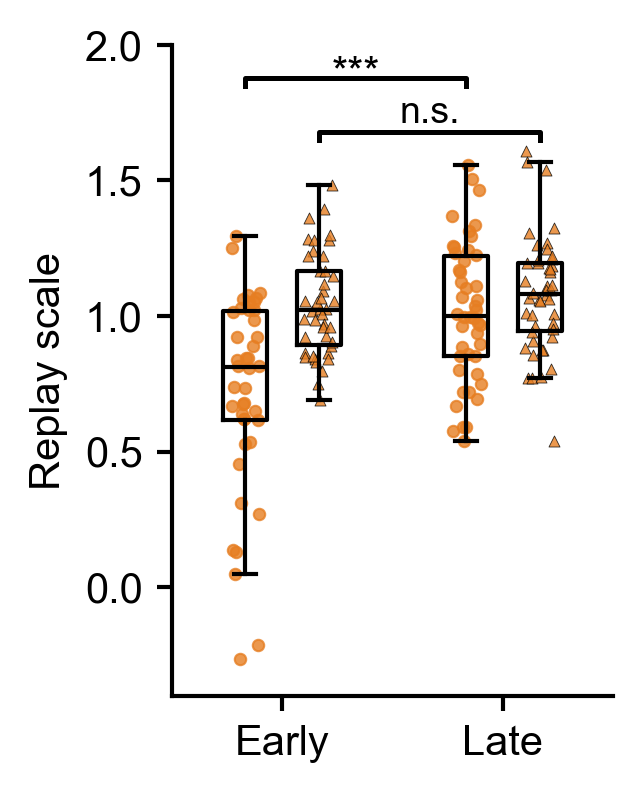

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../Results4Plots/replay_scale.csv')
dfp = df.copy()
dfp["replay_scale"] = pd.to_numeric(dfp["replay_scale"], errors="coerce")

dfp = dfp[
    (dfp["stage"].isin(["early", "late"]))
    & (dfp["env"].isin(["R", "VR"]))
    & (dfp["replay_scale"].notna())
].copy()

stage_levels = ["early", "late"]
env_levels = ["R", "VR"]

colorReplay = np.array([230, 126, 34]) / 255.0

xpos = {
    ("early", "VR"): 1,
    ("early", "R"): 2,
    ("late", "VR"): 4,
    ("late", "R"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2, 2.5), dpi=300)

for st in stage_levels:
    for env in env_levels:
        sub = dfp[(dfp["stage"] == st) & (dfp["env"] == env)]
        y = sub["replay_scale"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, env)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if env == "VR":
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorReplay, edgecolors=colorReplay, linewidths=0.5, alpha=0.8, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7, marker="^", facecolors=colorReplay, edgecolors="k", linewidths=0.2, alpha=0.8, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Replay scale", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

r_values = dfp.loc[dfp["env"] == "R", "replay_scale"].to_numpy(dtype=float)
vr_values = dfp.loc[dfp["env"] == "VR", "replay_scale"].to_numpy(dtype=float)

r_values = r_values[np.isfinite(r_values)]
vr_values = vr_values[np.isfinite(vr_values)]

y_r = np.nanmax(r_values) + gap
y_vr = np.nanmax(vr_values) + gap + 0.12 * yr

ax.plot([2, 2, 5, 5], [y_r, y_r + h, y_r + h, y_r], lw=1.2, c="k")
ax.text(3.5, y_r + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([1, 1, 4, 4], [y_vr, y_vr + h, y_vr + h, y_vr], lw=1.2, c="k")
ax.text(2.5, y_vr + h + text_offset - 0.03 * yr - 0.01, "***", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.set_ylim(-0.4, 2)
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()